In [172]:
import ast
import os
import networkx as nx
import community as community_louvain
from collections import defaultdict
from matplotlib import pyplot as plt
import seaborn as sns
import nbformat
from nbconvert import PythonExporter
from pyvis.network import Network

In [2]:
class CallGraphVisitor(ast.NodeVisitor):
    def __init__(self, filepath, global_functions, base_dir):
        self.filepath = os.path.relpath(filepath, base_dir)
        self.base_dir = base_dir
        self.global_functions = global_functions

        self.current_function = None
        self.current_class = None
        self.calls = []
        self.functions = []
        self.imports = {}  # alias -> file path

    # --- Import tracking ---
    def visit_Import(self, node):
        for alias in node.names:
            module_name = alias.name  # e.g., "utils.helper"
            asname = alias.asname or module_name.split(".")[-1]
            module_path = self._resolve_module_to_path(module_name)
            if module_path:
                self.imports[asname] = module_path
        self.generic_visit(node)

    def visit_ImportFrom(self, node):
        # e.g., from example02 import y
        if node.module:
            module_name = node.module
            module_path = self._resolve_module_to_path(module_name)
            for alias in node.names:
                asname = alias.asname or alias.name
                self.imports[asname] = module_path
        self.generic_visit(node)

    def _resolve_module_to_path(self, module_name):
        """Convert module name to file path if exists in the project."""
        path_guess = os.path.join(self.base_dir, *module_name.split(".")) + ".py"
        if os.path.exists(path_guess):
            return os.path.relpath(path_guess, self.base_dir)
        return None

    # --- Class and function tracking ---
    def visit_ClassDef(self, node):
        prev_class = self.current_class
        self.current_class = node.name
        self.generic_visit(node)
        self.current_class = prev_class

    def visit_FunctionDef(self, node):
        if self.current_class:
            full_name = f"{self.filepath}:{self.current_class}.{node.name}"
            short_name = f"{self.current_class}.{node.name}"
        else:
            full_name = f"{self.filepath}:{node.name}"
            short_name = node.name

        self.functions.append({
            "full_name": full_name,
            "short_name": short_name,
            "class_name": self.current_class,
            "filepath": self.filepath,
            "lineno": node.lineno,
            "col_offset": node.col_offset
        })

        self.global_functions.setdefault(short_name, []).append(full_name)

        prev_function = self.current_function
        self.current_function = full_name
        self.generic_visit(node)
        self.current_function = prev_function

    # --- Call tracking ---
    def visit_Call(self, node):
        # If not inside a function, treat it as a top-level (module) call
        caller = self.current_function or f"{self.filepath}:<module>"

        callee_full = None

        # Case 1: direct call like y()
        if isinstance(node.func, ast.Name):
            name = node.func.id
            if name in self.imports and self.imports[name]:
                callee_file = self.imports[name]
                matches = self.global_functions.get(name, [])
                if matches:
                    callee_full = matches[0].replace(matches[0].split(":")[0], callee_file)
                else:
                    callee_full = f"{callee_file}:{name}"
            elif name in self.global_functions:
                callee_full = self.global_functions[name][0]
            else:
                callee_full = name

        # Case 2: attribute call like mod.func()
        elif isinstance(node.func, ast.Attribute):
            value = getattr(node.func.value, "id", None)
            attr = node.func.attr
            if value and value in self.imports and self.imports[value]:
                callee_file = self.imports[value]
                callee_full = f"{callee_file}:{attr}"
            else:
                callee_full = attr

        if callee_full:
            self.calls.append((caller, callee_full))

        self.generic_visit(node)


In [41]:
class FunctionCollector(ast.NodeVisitor):
    """Collect all top-level functions and class methods."""
    def __init__(self, filename):
        self.filename = filename
        self.functions = {}  # {full_func_name: node}
        self.class_defs = {}  # {full_class_name: node}
        self.current_class = None

    def visit_ClassDef(self, node):
        class_name = f"{self.filename}:{node.name}"
        self.class_defs[class_name] = node

        prev_class = self.current_class
        self.current_class = node.name
        self.generic_visit(node)
        self.current_class = prev_class

    def visit_FunctionDef(self, node):
        if self.current_class:
            # Class method
            full_name = f"{self.filename}:{self.current_class}.{node.name}"
        else:
            # Top-level function
            full_name = f"{self.filename}:{node.name}"
        self.functions[full_name] = node
        self.generic_visit(node)

def get_py_files(root_dir):
    py_files = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".py"):
                py_files.append(os.path.join(root, file))
    return py_files

def get_ipynb_files(root_dir):
    ipynb_files = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".ipynb"):
                ipynb_files.append(os.path.join(root, file))
    return ipynb_files

def build_call_graph(root_dir):
    global_functions = {}
    G = nx.DiGraph()
    py_files = get_py_files(root_dir)
    ipynb_files = get_ipynb_files(root_dir)
    for file in py_files:
        with open(file, "r", encoding="utf-8") as f:
            try:
                tree = ast.parse(f.read(), filename=file)
                visitor = CallGraphVisitor(file, global_functions, root_dir)
                visitor.visit(tree)
                for caller, callee in visitor.calls:
                    if ":" not in callee:
                        continue
                    G.add_edge(caller, callee)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    for file in ipynb_files:
        if file.endswith(".ipynb"):
            try:
                with open(file, "r", encoding="utf-8") as f:
                    nb = nbformat.read(f, as_version=4)
                    exporter = PythonExporter()
                    source, _ = exporter.from_notebook_node(nb)
                    tree = ast.parse(source, filename=file)
                    visitor = CallGraphVisitor(file, global_functions, root_dir)
                    visitor.visit(tree)
                    for caller, callee in visitor.calls:
                        if ":" not in callee:
                            continue
                        G.add_edge(caller, callee)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    return {'graph':G,'py_count':len(py_files),'ipynb_count':len(ipynb_files)}

def collect_all_definitions(root_dir):
    """Return dicts for functions and classes with their AST nodes."""
    all_functions = {}
    all_classes = {}
    for file in get_py_files(root_dir):
        with open(file, "r", encoding="utf-8") as f:
            try:
                tree = ast.parse(f.read(), filename=file)
                collector = FunctionCollector(file)
                collector.visit(tree)
                all_functions.update(collector.functions)
                all_classes.update(collector.class_defs)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    for file in get_ipynb_files(root_dir):
        if file.endswith(".ipynb"):
            try:
                with open(file, "r", encoding="utf-8") as f:
                    nb = nbformat.read(f, as_version=4)
                    exporter = PythonExporter()
                    source, _ = exporter.from_notebook_node(nb)
                    tree = ast.parse(source, filename=file)
                    collector = FunctionCollector(file)
                    collector.visit(tree)
                    all_functions.update(collector.functions)
                    all_classes.update(collector.class_defs)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    return all_functions, all_classes

# --- Refactor: split into compute_clusters and save_clusters ---

def compute_clusters(repo_path,random_state = 42,resolution=1):
    """
    Analyze the repository at `repo_path` and compute clustering of call graph nodes.

    Returns:
        clusters: dict[int, list[str]]  -- mapping cluster_id -> list of node names
        all_functions: dict[str, ast.AST] -- mapping function full names to AST nodes
        all_classes: dict[str, ast.AST]   -- mapping class full names to AST nodes
        output_dir: str                       -- suggested output directory for saving clusters
    """
    output_dir = f"result/repo_callgraph_clusters/{repo_path.split('/')[-1]}"
    os.makedirs(output_dir, exist_ok=True)

    # Build the call graph and partition it
    graph_builder = build_call_graph(repo_path)
    graph_undirected = graph_builder['graph'].to_undirected()
    py_count = graph_builder['py_count']
    ipynb_count = graph_builder['ipynb_count']
    

    # Collect all functions and classes
    all_functions, all_classes = collect_all_definitions(repo_path)

    partition = community_louvain.best_partition(graph_undirected,random_state=random_state,resolution=resolution)
    # Build cluster mapping (cluster_id -> list of nodes)
    clusters = defaultdict(list)
    for node, cluster_id in partition.items():
        clusters[cluster_id].append(node)

    # partition = list(nx.connected_components(graph_undirected))
    # for cluster_id,node in enumerate(partition):
    #     clusters[cluster_id].append(node)
    return clusters, all_functions, all_classes, output_dir, py_count, ipynb_count


def save_clusters(clusters, all_functions, all_classes, output_dir,root_dir=""):
    """
    Save computed clusters into Python files under `output_dir`.

    This function writes one file per cluster and attempts to unparse
    class and function AST nodes back to source code. It avoids duplicate
    class writes when multiple class methods appear in the same cluster.
    """
    for cluster_id, nodes in clusters.items():
        file_path = os.path.join(output_dir, f"cluster_{cluster_id}.py")
        written_classes = set()  # Avoid duplicate class writing
        written_functions = set()

        with open(file_path, "w", encoding="utf-8") as out:
            out.write(f"# Cluster {cluster_id}\n\n")

            for node_name in nodes:
                node_name = root_dir + "/" + node_name
                # If it's a class method, include the entire class
                for class_name, class_node in all_classes.items():
                    if node_name.startswith(class_name + ".") and class_name not in written_classes:
                        try:
                            source = ast.unparse(class_node)
                            # print("="*30+f"  {class_name}  "+"="*30)
                            # print(source)
                            # print("="*100)
                            out.write(source + "\n\n")
                            written_classes.add(class_name)
                        except Exception:
                            out.write(f"# Could not unparse {class_name}\n\n")

                # If it's a standalone function
                if node_name in all_functions and node_name not in written_functions:
                    is_written = False
                    for written_class in written_classes:
                        if node_name.startswith(written_class+'.'):
                            is_written=True
                            break
                    if not is_written:
                        try:
                            source = ast.unparse(all_functions[node_name])
                            # print("+"*30+f"  {node_name}  "+"+"*30)
                            # print(source)
                            # print("="*100)
                            out.write(source + "\n\n")
                        except Exception:
                            out.write(f"# Could not unparse {node_name}\n\n")

        print(f"✅ cluster_{cluster_id}.py saved with {len(nodes)} entries")

    print("\nAll cluster code files are in:", output_dir)


def cluster_and_save_code(repo_path):
    """Compatibility wrapper that computes clusters and saves them to files."""
    clusters, all_functions, all_classes, output_dir, py_count, ipynb_count = compute_clusters(repo_path,resolution=2,random_state=1)
    save_clusters(clusters, all_functions, all_classes, output_dir,root_dir=repo_path)


In [177]:
graph = build_call_graph("./monkey-net")
G = graph['graph']
net = Network(height="100vh", width="100%",)
net.add_nodes(G.nodes)
net.add_edges(G.edges)
net.show_buttons(filter_=['physics'])
net.write_html('graph2.html')

In [190]:
def generate_html_graph(repo_dir,out_dir='./result/graph-network'):
    graph = build_call_graph(repo_dir)
    G = graph['graph']

    # Create PyVis network
    net = Network(height="100vh", width="100%", directed=True, bgcolor="#FFFFFF", font_color="black")

    # Better physics engine
    net.barnes_hut(
        gravity=-5000,
        spring_length=150,
        central_gravity=0.25,
        spring_strength=0.02,
    )

    # Color palette for files
    colors = [
        "#EF476F", "#06D6A0", "#118AB2", "#FFD166", 
        "#073B4C", "#9B5DE5", "#F15BB5", "#00BBF9",
        "#00F5D4", "#FEE440", "#FF7D00", "#FF006E"
    ]

    # Map: file → color
    file_colors = {}
    color_index = 0

    def get_color(node):
        global color_index
        file = node.split(":")[0]
        if file not in file_colors:
            file_colors[file] = colors[color_index % len(colors)]
            color_index += 1
        return file_colors[file]

    # Add nodes with coloring, tooltips and sizing
    for node in G.nodes():
        file, func = node.split(":", 1)

        degree = G.degree(node)
        size = 10 + degree * 2

        net.add_node(
            node,
            label=func,              # only function name as label
            title=f"<b>File:</b> {file}\n<b>Function:</b> {func}",  # tooltip
            color=get_color(node),
            size=size,
            shape="dot"
        )

    # Add edges with arrows
    for u, v in G.edges():
        net.add_edge(
            u, v,
            arrows="to",
            color="#555555",
            width=1.5
        )

    # Optional: Show physics control panel
    net.show_buttons(filter_=["physics"])

    # Save output
    os.makedirs(out_dir,exist_ok=True)
    net.write_html(f"{out_dir}/{repo_dir.split('/')[-1]}.html")
    print(f"Saved {out_dir}/{repo_dir.split('/')[-1]}.html")


In [ ]:
for i in os.walk("/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos",):
    print(i)

('/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos', ['pytorch_RVAE', 'DI-sheep', 'HackBot', 'mexican-government-report', 'PentestAgent', 'WebShop', 'Styleformer', 'DeepLearning-IDS', 'pomdp-baselines', 'YOLO3D', 'Autonomous-Driving-in-Carla-using-Deep-Reinforcement-Learning', 'scattertext', 'ai-goat', 'surpriver', 'customizable-gpt-chatbot', 'CAAFE', 'mahalanobis_3d_multi_object_tracking', 'torchio', 'FuxiCTR', 'dalle-flow', 'VectorizedMultiAgentSimulator', 'MIRNetv2', 'RLMRec', 'mAP', 'v2x-vit', 'GPT_Vuln-analyzer', 'tf.fashionAI', 'ArxivDigest', 'OpenLearning4DeepRecsys', 'semantic-router', 'PointTransformerV2', 'DRL-Pytorch', 'Stride-AI-Agents', 'sumo-rl', 'optillm', 'transfuser', 'crafter', 'vigil-llm', 'synthetic-data-generator', 'Reinforcement_Learning_in_Python', 'computer-agent', 'adaptive-classifier', 'Automatic_Speech_Recognition', 'ladi-vton', 'Network-Intrusion-Detection', 'CyberScraper-2077', 'evadb', 'nuplan-devkit', 'Social-Dista

In [194]:
for _,sub,files in os.walk("/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos"):
    print(files)
    # generate_html_graph('./monkey-net')

[]
['train.py', 'train_word_embeddings.py', '__init__.py', 'sample.py', '.gitignore', 'README.md', 'LICENSE']
['embedding.py', 'tdnn.py', '__init__.py', 'neg.py', 'highway.py']
['batch_loader.py', 'functional.py', 'visualize_word_embeddings.py', '__init__.py', 'parameters.py']
['train.txt', 'test.txt']
['description', 'packed-refs', 'index', 'HEAD', 'shallow', 'config']
[]
[]
[]
['HEAD']
['master']
[]
['HEAD']
[]
[]
['HEAD']
['master']
['exclude']
[]
['pack-153d2737643ad2392d871146b101e076ca6d145f.idx', 'pack-153d2737643ad2392d871146b101e076ca6d145f.rev', 'pack-153d2737643ad2392d871146b101e076ca6d145f.pack']
[]
['sendemail-validate.sample', 'pre-rebase.sample', 'update.sample', 'fsmonitor-watchman.sample', 'pre-commit.sample', 'push-to-checkout.sample', 'applypatch-msg.sample', 'post-update.sample', 'prepare-commit-msg.sample', 'pre-push.sample', 'pre-applypatch.sample', 'pre-merge-commit.sample', 'commit-msg.sample', 'pre-receive.sample']
['decoder.py', '__init__.py', 'rvae.py', 'enco

In [171]:
def transform(name):
    file, func = name.split(":", 1)
    if '<module>' in func:
        return file.split('/')[-1]
    return func

G2 = nx.relabel_nodes(G, transform)
for node1,node2 in zip(G.nodes,G2.nodes):
    print(node1,'---->',node2)
nx.write_gexf(G2, "graph.gexf")

train.py:GeneratorFullModel.forward ----> GeneratorFullModel.forward
train.py:split_kp ----> split_kp
modules/losses.py:generator_loss ----> generator_loss
train.py:DiscriminatorFullModel.forward ----> DiscriminatorFullModel.forward
modules/losses.py:discriminator_loss ----> discriminator_loss
train.py:train ----> train
logger.py:load_cpk ----> load_cpk
logger.py:Logger ----> Logger
modules/losses.py:generator_loss_names ----> generator_loss_names
modules/losses.py:discriminator_loss_names ----> discriminator_loss_names
prediction.py:KPDataset.__init__ ----> KPDataset.__init__
augmentation.py:SelectRandomFrames ----> SelectRandomFrames
prediction.py:prediction ----> prediction
frames_dataset.py:FramesDataset ----> FramesDataset
augmentation.py:VideoToTensor ----> VideoToTensor
modules/prediction_module.py:PredictionModule ----> PredictionModule
reconstruction.py:generate ----> generate
logger.py:Visualizer ----> Visualizer
demo.py:<module> ----> demo.py
modules/generator.py:MotionTrans

In [37]:
cluster_and_save_code("./ai-goat")

Total Python files found in ai-goat: 8
Total Jupyter notebook files found in ai-goat: 0
Detected 7 clusters in the call graph.
✅ cluster_0.py saved with 1 entries
✅ cluster_1.py saved with 3 entries
✅ cluster_4.py saved with 1 entries
✅ cluster_5.py saved with 1 entries
✅ cluster_6.py saved with 1 entries
✅ cluster_3.py saved with 1 entries
✅ cluster_2.py saved with 3 entries

All cluster code files are in: result/repo_callgraph_clusters/ai-goat


./ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
./ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"
./ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
./ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"


In [54]:
# repo_dir = "./monkey-net"
def plot_cluster_size_distribution(repo_dir):
    clusters, all_functions, all_classes, output_dir, py_count, ipynb_count = compute_clusters(repo_dir,resolution=2,random_state=1)
    print("Summary:")
    print(" - Repository analyzed".ljust(26)+':', repo_dir.split('/')[-1])
    print(" - Total Python files".ljust(26)+':', py_count)
    print(" - Total Jupyter notebooks".ljust(26)+':', ipynb_count)
    print(" - Functions/Methods found".ljust(26)+':', len(all_functions))
    print(" - Classes found".ljust(26)+':', len(all_classes))
    print(" - Clusters found".ljust(26)+':', len(clusters))
    cluster_and_save_code(repo_dir)
    plt.figure(figsize=(10, 6))
    sns.barplot(y=[(len(clusters[cluster])) for cluster in clusters.keys()],
                x=list(clusters.keys()))
    plt.title(f"Cluster Size Distribution for {repo_dir.split('/')[-1]}")
    plt.ylabel("Number of Functions/Methods in Cluster")
    plt.xlabel("Cluster Number")
    plt.show()

Summary:
 - Repository analyzed    : monkey-net
 - Total Python files     : 25
 - Total Jupyter notebooks: 0
 - Functions/Methods found: 140
 - Classes found          : 41
 - Clusters found         : 16
✅ cluster_0.py saved with 9 entries
✅ cluster_2.py saved with 4 entries
✅ cluster_3.py saved with 11 entries
✅ cluster_4.py saved with 2 entries
✅ cluster_5.py saved with 8 entries
✅ cluster_6.py saved with 3 entries
✅ cluster_7.py saved with 2 entries
✅ cluster_8.py saved with 3 entries
✅ cluster_9.py saved with 9 entries
✅ cluster_10.py saved with 3 entries
✅ cluster_11.py saved with 3 entries
✅ cluster_12.py saved with 2 entries
✅ cluster_13.py saved with 2 entries
✅ cluster_14.py saved with 6 entries
✅ cluster_15.py saved with 6 entries
✅ cluster_1.py saved with 5 entries

All cluster code files are in: result/repo_callgraph_clusters/monkey-net


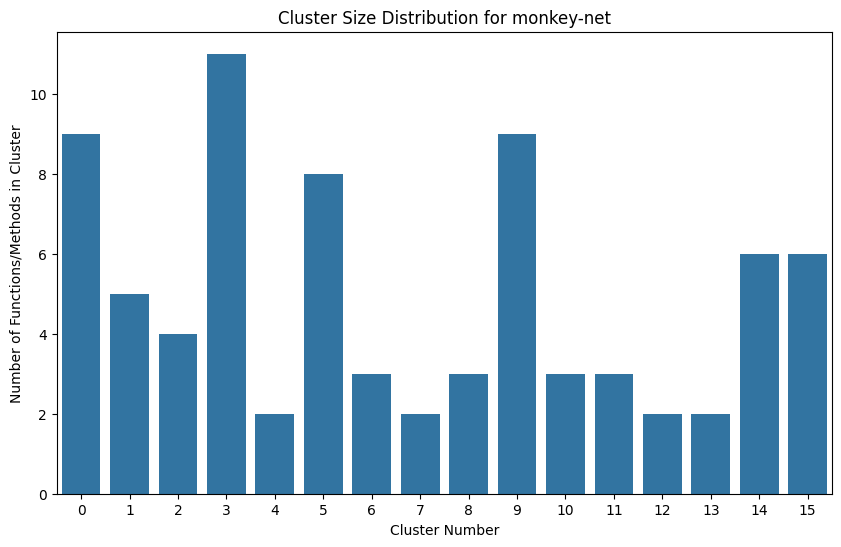

./ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
./ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"
./ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
./ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"
./ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
./ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"
./ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
./ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"


Summary:
 - Repository analyzed    : ai-goat
 - Total Python files     : 8
 - Total Jupyter notebooks: 0
 - Functions/Methods found: 19
 - Classes found          : 3
 - Clusters found         : 7
✅ cluster_0.py saved with 1 entries
✅ cluster_1.py saved with 3 entries
✅ cluster_4.py saved with 1 entries
✅ cluster_5.py saved with 1 entries
✅ cluster_6.py saved with 1 entries
✅ cluster_3.py saved with 1 entries
✅ cluster_2.py saved with 3 entries

All cluster code files are in: result/repo_callgraph_clusters/ai-goat


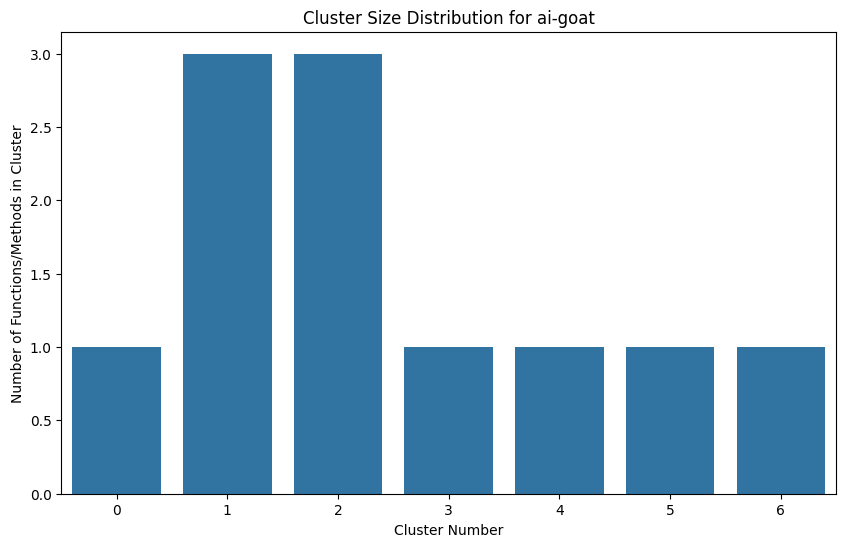

./AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)
./AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)


Summary:
 - Repository analyzed    : AgentBench
 - Total Python files     : 83
 - Total Jupyter notebooks: 0
 - Functions/Methods found: 276
 - Classes found          : 81
 - Clusters found         : 21


./AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)
./AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)


✅ cluster_0.py saved with 22 entries
✅ cluster_1.py saved with 8 entries
✅ cluster_2.py saved with 2 entries
✅ cluster_3.py saved with 3 entries
✅ cluster_4.py saved with 4 entries
✅ cluster_5.py saved with 10 entries
✅ cluster_8.py saved with 3 entries
✅ cluster_9.py saved with 5 entries
✅ cluster_12.py saved with 1 entries
✅ cluster_7.py saved with 3 entries
✅ cluster_14.py saved with 1 entries
✅ cluster_15.py saved with 1 entries
✅ cluster_16.py saved with 1 entries
✅ cluster_17.py saved with 2 entries
✅ cluster_18.py saved with 4 entries
✅ cluster_19.py saved with 4 entries
✅ cluster_20.py saved with 3 entries
✅ cluster_13.py saved with 1 entries
✅ cluster_6.py saved with 4 entries
✅ cluster_10.py saved with 3 entries
✅ cluster_11.py saved with 2 entries

All cluster code files are in: result/repo_callgraph_clusters/AgentBench


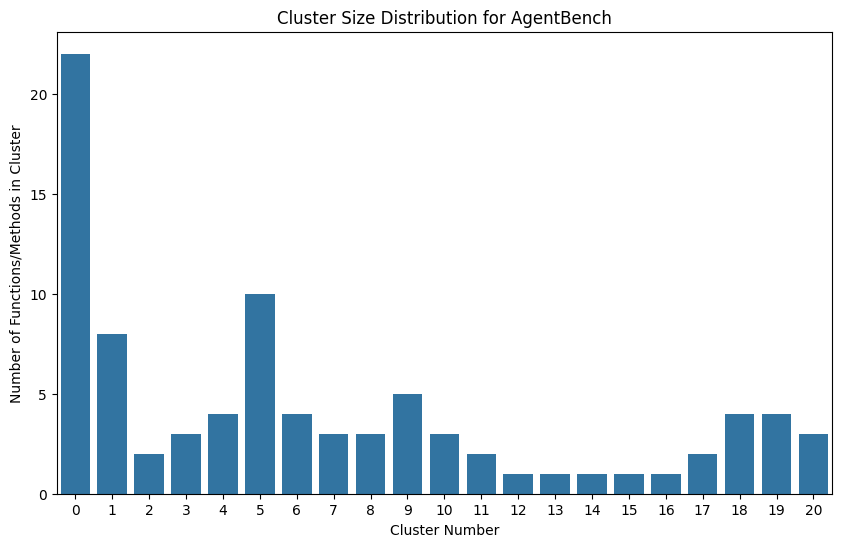

In [55]:
for repo_dir in ["./monkey-net","./ai-goat","./AgentBench"]:
    plot_cluster_size_distribution(repo_dir)

In [115]:
all_functions

{'./rag-app/retriever.py:retrieve_context': <ast.FunctionDef at 0x70d616ad8350>,
 './rag-app/embedder.py:get_text_embedding': <ast.FunctionDef at 0x70d618046410>,
 './rag-app/vector_store.py:add_document': <ast.FunctionDef at 0x70d616c6a610>,
 './rag-app/vector_store.py:search_similar': <ast.FunctionDef at 0x70d617bde590>,
 './rag-app/rag_chain.py:generate_answer': <ast.FunctionDef at 0x70d617efafd0>}

In [123]:
for i in clusters.keys():
    print(f"Cluster {i}: {len(clusters[i])} functions/methods")

    print("Functions/Methods in Cluster:")
    not_in_files = set(clusters[i])

    for j in all_classes.keys():
        j = j.replace(repo_dir+"/","")
        if j in clusters[i]:
            not_in_files.discard(j)
            print(f"  - {j}")
    for j in all_functions.keys():
        j = j.replace(repo_dir+"/","")
        if j in clusters[i]:
            not_in_files.discard(j)
            print(f"  - {j}")
    
    print("Not found in collected definitions:")
    for item in not_in_files:
        print(f"  - {item}")

    print("Full Cluster Content:")
    for item in clusters[i]:
        print(f"  - {item}")
    print("-" * 60)

Cluster 0: 3 functions/methods
Functions/Methods in Cluster:
  - retriever.py:retrieve_context
  - rag_chain.py:generate_answer
Not found in collected definitions:
  - config.py:GenerativeModel
Full Cluster Content:
  - retriever.py:retrieve_context
  - rag_chain.py:generate_answer
  - config.py:GenerativeModel
------------------------------------------------------------
Cluster 1: 2 functions/methods
Functions/Methods in Cluster:
  - vector_store.py:search_similar
Not found in collected definitions:
  - config.py:query
Full Cluster Content:
  - vector_store.py:search_similar
  - config.py:query
------------------------------------------------------------
Cluster 2: 4 functions/methods
Functions/Methods in Cluster:
  - embedder.py:get_text_embedding
  - vector_store.py:add_document
Not found in collected definitions:
  - config.py:embed_content
  - config.py:upsert
Full Cluster Content:
  - embedder.py:get_text_embedding
  - config.py:embed_content
  - vector_store.py:add_document
  - 

In [ ]:
cluster_and_save_code("./rag-app")

retriever.py:retrieve_context vector_store.py:search_similar
embedder.py:get_text_embedding config.py:embed_content
vector_store.py:add_document embedder.py:get_text_embedding
vector_store.py:add_document config.py:upsert
vector_store.py:search_similar embedder.py:get_text_embedding
vector_store.py:search_similar config.py:query
rag_chain.py:generate_answer retriever.py:retrieve_context
rag_chain.py:generate_answer config.py:GenerativeModel
Graph with 9 nodes and 8 edges
✅ cluster_0.py saved with 3 entries
✅ cluster_1.py saved with 2 entries
✅ cluster_2.py saved with 4 entries

All cluster code files are in: result/repo_callgraph_clusters/rag-app


In [74]:
clusters[1]

['./monkey-net/train.py:split_kp',
 'detach',
 'items',
 './monkey-net/train.py:GeneratorFullModel.forward',
 'kp_extractor',
 'generator',
 'split_kp',
 'discriminator',
 'update',
 'generator_loss',
 'tuple',
 './monkey-net/train.py:DiscriminatorFullModel.forward',
 'discriminator_loss',
 'kp_detector',
 './monkey-net/frames_dataset.py:PairedDataset.__getitem__',
 './monkey-net/transfer.py:transfer_one',
 'cat_dict',
 'normalize_kp']